In [173]:
#libraries
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim
import numpy as np
from tqdm import tqdm
import xgboost as xgb
from sklearn.decomposition import PCA


In [ ]:
df = pl.read_parquet("data/microcap.parquet")

df = df.sort(["permno", "month"]).with_columns([
    pl.col("bidask").shift(1).over("permno").alias("bidask_lag"),
    pl.col("vol").shift(1).over("permno").alias("vol_lag"),
])

chars = [
    "size", "momentum", "bm", "roa", "leverage",
    "bidask_lag", "vol_lag", "total_assets", "book_equity",
    "net_income", "gross_profit",
]

In [167]:
#DATA CLEANING

def clean_data(df, chars, target="excess_ret"):
    df = df.drop_nulls(subset=chars + [target])

    lower = df.select(pl.col(target).quantile(0.01)).item()
    upper = df.select(pl.col(target).quantile(0.99)).item()

    df = df.with_columns(
        pl.col(target).clip(lower, upper)
    )

    return df


#RANK STANDARDIZATION

def rank_standardize(df, chars):
    """
    Cross-sectional rank standardization per month to [-0.5, 0.5]
    """

    for c in chars:
        df = df.with_columns(
            (
                pl.col(c).rank("average").over("month")
                / (pl.count().over("month") + 1)
                - 0.5
            ).alias(c)
        )
    return df

#batch for efficient operations in modeling
def make_batches(df, chars, target="excess_ret"):
    months = sorted(df["month"].unique())
    batches = []

    for d in df.partition_by("month"):
        if len(d) < 10:
            continue

        Z = torch.tensor(d[chars].to_numpy(), dtype=torch.float32)
        R = torch.tensor(d[target].to_numpy(), dtype=torch.float32)

        batches.append((Z, R))

    return batches


In [168]:
df = clean_data(df, chars)
df = rank_standardize(df, chars)

C:\Users\reyno\AppData\Local\Temp\ipykernel_24336\1887542401.py:27: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  / (pl.count().over("month") + 1)


In [169]:
def time_split(df, train=0.6, val=0.2):
    months = sorted(df["month"].unique())
    T = len(months)

    t1 = int(train*T)
    t2 = int((train+val)*T)

    train_df = df.filter(pl.col("month") < months[t1])
    val_df   = df.filter((pl.col("month") >= months[t1]) & (pl.col("month") < months[t2]))
    test_df  = df.filter(pl.col("month") >= months[t2])

    return train_df, val_df, test_df

In [170]:
train_df, val_df, test_df = time_split(df)

In [171]:
def prepare_tensors(df, chars):
    """Converts dataframe to (N, T, L) tensor and (N, T) matrix."""
    pivot_r = df.pivot(index="permno", on="month", values="excess_ret").sort("permno")
    R = pivot_r.drop("permno").to_numpy()
    
    months = sorted(df["month"].unique())
    permnos = sorted(df["permno"].unique())

    T = len(months)
    N = len(permnos)
    # add one for intercept column
    L_plus = len(chars) + 1
    Z = np.zeros((N, T, L_plus))

    Z[:, :, 0] = 1.0  # Intercept term
    
    for i, char in enumerate(chars):
        z_pivot = df.pivot(index="permno", on="month", values=char).sort("permno")
        Z[:, :, i+1] = z_pivot.drop("permno").to_numpy()
    return R, Z

R_train, Z_train = prepare_tensors(train_df,chars)
R_test, Z_test = prepare_tensors(test_df, chars)

# FF5

In [ ]:
import pandas_datareader.data as web
import polars as pl

#5-factor 2x3 dataset
ds = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench', start='1995-01-01')

#Extract the monthly table (index 0). Index 1 contains the annual factors.
ff_5_factors = ds[0]

#FF data is provided in percentage form (e.g., 1.05 = 1.05%). 
factors_to_scale = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
ff_5_factors[factors_to_scale] = ff_5_factors[factors_to_scale] / 100

ff_5_factors.index = ff_5_factors.index.to_timestamp()
ff_5_factors = ff_5_factors.reset_index().rename(columns={'Date': 'month'})

ff_5_pl = pl.from_pandas(ff_5_factors)

ff_5_pl = ff_5_pl.rename({'Mkt-RF': 'MktRF'})

print("Fama-French 5-Factor Head:")
print(ff_5_pl.head())

C:\Users\reyno\AppData\Local\Temp\ipykernel_24336\2020707307.py:5: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ds = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench', start='1995-01-01')
C:\Users\reyno\AppData\Local\Temp\ipykernel_24336\2020707307.py:5: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ds = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench', start='1995-01-01')


Fama-French 5-Factor Head:
shape: (5, 7)
┌─────────────────────┬────────┬─────────┬─────────┬─────────┬─────────┬────────┐
│ month               ┆ MktRF  ┆ SMB     ┆ HML     ┆ RMW     ┆ CMA     ┆ RF     │
│ ---                 ┆ ---    ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---    │
│ datetime[ns]        ┆ f64    ┆ f64     ┆ f64     ┆ f64     ┆ f64     ┆ f64    │
╞═════════════════════╪════════╪═════════╪═════════╪═════════╪═════════╪════════╡
│ 1995-01-01 00:00:00 ┆ 0.018  ┆ -0.0307 ┆ 0.0259  ┆ 0.0015  ┆ -0.0065 ┆ 0.0042 │
│ 1995-02-01 00:00:00 ┆ 0.0363 ┆ -0.0049 ┆ 0.0099  ┆ 0.0061  ┆ -0.004  ┆ 0.004  │
│ 1995-03-01 00:00:00 ┆ 0.0219 ┆ -0.0053 ┆ -0.0213 ┆ -0.0013 ┆ 0.0023  ┆ 0.0046 │
│ 1995-04-01 00:00:00 ┆ 0.0211 ┆ -0.0026 ┆ 0.0167  ┆ 0.0043  ┆ 0.0082  ┆ 0.0044 │
│ 1995-05-01 00:00:00 ┆ 0.029  ┆ -0.0217 ┆ 0.0228  ┆ 0.0041  ┆ 0.0001  ┆ 0.0054 │
└─────────────────────┴────────┴─────────┴─────────┴─────────┴─────────┴────────┘


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS

#allingn
factors = ['MktRF', 'SMB', 'HML', 'RMW', 'CMA']
df_oos = panelFF5.join(ff_5_pl, on="month").sort(["permno", "month"]).to_pandas()

# --- STEP 2: ROLLING BETA ESTIMATION ---
def estimate_individual_betas(group, window=60):
    if len(group) < window + 1:
        return None
    y = group['excess_ret']
    X = sm.add_constant(group[factors])
    model = RollingOLS(y, X, window=window)
    rolling_res = model.fit()
    betas = rolling_res.params.shift(1)
    betas.columns = [f'beta_{c}' if c != 'const' else 'alpha' for c in betas.columns]
    return betas

print("Estimating individual stock betas (60m rolling)...")
beta_panel = df_oos.groupby('permno', group_keys=False).apply(
    lambda x: estimate_individual_betas(x), include_groups=False
)
df_final = pd.concat([df_oos, beta_panel], axis=1).dropna(subset=['alpha'])

#forecast
for f in factors:
    global_factor_mean = df_final[['month', f]].drop_duplicates().sort_values('month')
    global_factor_mean[f'{f}_mean'] = global_factor_mean[f].expanding().mean().shift(1)
    df_final = df_final.merge(global_factor_mean[['month', f'{f}_mean']], on='month', how='left')

df_final['predicted'] = df_final['alpha'] + sum(
    df_final[f'beta_{f}'] * df_final[f'{f}_mean'] for f in factors
)

results_df = df_final.dropna(subset=['predicted']).copy()

#noise reshuffling
results_df['predicted_noise'] = results_df.groupby('month')['predicted'].transform(
    lambda x: np.random.permutation(x.values)
)

#performance
actual = results_df['excess_ret'].values
pred = results_df['predicted'].values
pred_noise = results_df['predicted_noise'].values

ss_res = np.sum((actual - pred) ** 2)
ss_res_noise = np.sum((actual - pred_noise) ** 2)
ss_total_zero = np.sum(actual ** 2)
ss_total_mean = np.sum((actual - np.mean(actual)) ** 2)

r2_explanatory = 1 - (ss_res / ss_total_zero)
r2_predictive = 1 - (ss_res / ss_total_mean)
r2_noise = 1 - (ss_res_noise / ss_total_zero)

print(f"\n{'='*60}")
print(f"{'FF5 PERFORMANCE':^60}")
print(f"{'='*60}")
print(f"  Explanatory OOS R² (Zero-Based):     {r2_explanatory:>12.6%}")
print(f"  Predictive OOS R² (Mean-Based):      {r2_predictive:>12.6%}")
print(f"  Noise R² (Shuffled Baseline):        {r2_noise:>12.6%}")
print(f"{'='*60}")

Estimating individual stock betas (60m rolling)...

   OFFICIAL FF5 OOS EVALUATION: PERFORMANCE & ROBUSTNESS    
  Explanatory OOS R² (Zero-Based):       -1.021466%
  Predictive OOS R² (Mean-Based):        -1.567427%
  Noise R² (Shuffled Baseline):          -1.177448%


# IPCA

In [26]:
class IPCA:
    def __init__(self, K=5, reg=0.1, max_iter=50):
    #K: number of latent factors
    #reg: regularization coeff for mapping matrix estimaion
    #max_iter: max iterations for alternating least squares 
        self.K = K
        self.reg = reg
        self.max_iter = max_iter


    def fit(self, R, Z, mask):
        #R: 2D array (N, T) of returns
        #Z: 3D array (N, T, L) of characteristics
        #mask: 2D boolean array (N, T) indicating valid entries
        #note: N is num assets, T is num months, L is num characteristics
        N, T, L = Z.shape
        #use random normal dist for starting estimation of mapping matrix for K latent factors
        gamma = np.random.normal(0, 0.01, (L, self.K))
        #initialize latent factor matrix (F) with zeros so we can iteratively update with ALS
        F = np.zeros((self.K, T))

        #Alternating Least Squares loop
        #iteratively update mapping matrix (gamma) and latent factors (F),
        #until convergence or max iteration reached
        for _ in range(self.max_iter):
            #store gamma current-1 for convergence check
            gamma_old = gamma.copy()

            #estimate factors given current gamma
            for t in range(T):
                #check for valid entries in month t
                idx = mask[:, t]
                #if valid entries less than K, must skip month to avoid singular matrix in factor estimation
                if idx.sum() < self.K: continue
                #multiply NxL characteristics with LxK gamma matrix to get NxK factor loadings for month t
                #note: Z is NxTxL matrix of assets(N), months(T), characteristics(L), but we slice to get NxL for month t, 
                #then multiply by LxK gamma to get NxK factor loadings (Xt) for month t
                Xt = Z[idx, t, :] @ gamma
                #solve linear system Ax = b for x
                #I use A = Xt.T @ Xt + reg*I for Hessian ridge regression to handle potential multicollinearity and ensure numerical stability
                #np.eye(self.K) creates KxK identity matrix for regularization
                # Xt.T @ R[idx,t] is the gradient, where loadings are transposed and multiplied by returns to get,
                #the direction of steepest descent for factor estimation
                F[:, t] = np.linalg.solve(Xt.T @ Xt + self.reg * np.eye(self.K), Xt.T @ R[idx, t])

            #estimate gamma given current factors
            #initialize A to zero'd out hessian matrix, and b to zero'd out gradient vector for gamma estimation
            A, b = np.zeros((L*self.K, L*self.K)), np.zeros(L*self.K)
            #loop through months to accumulate A and b for gamma estimation
            for t in range(T):
                #ensure valid entries in month t
                idx = mask[:, t]
                #if valid entries less than K, must skip month to avoid singular matrix in factor estimation
                if idx.sum() < self.K: continue
                #kronecker product of factors and characteristics for month t,
                #creating matrix where each row corresponds to an asset, and columns are interactions of characteristics and factors
                Xt_kron = np.kron(F[:, t], Z[idx, t, :])
                #update A with inner product of Xt Kronecker with itself and add to global pile
                A += Xt_kron.T @ Xt_kron
                #update b with product of Xt Kronecker and returns for month t and add to global pile
                b += Xt_kron.T @ R[idx, t]

            #A becomes A + self.reg * np.eye(L*self.K) is ridge regression and regularization handles multicollinearity where A might not be invertible
            #solving for (A,b).reshape(L, self.K) finds gamma vector that minimizes square error, then reshapes to LxK matrix
            gamma = np.linalg.solve(A + self.reg * np.eye(L*self.K), b).reshape(L, self.K)
            #QR decomposition of gamma to ensure factors are orthogonal and handle identification constraint. 
            #we take Q and assign to gamma, and discard R to _ since we only care about orthogonalized gamma
            gamma, _ = np.linalg.qr(gamma) # Identification constraint

            #find frobenius norm of diff between updated gamma and prior gamma to check for convergence,
            #if the difference in gamma is below threshold, we have reached convergence so we break out of loop
            if np.linalg.norm(gamma - gamma_old) < 1e-5: break

        #we transfer identified gamma and factors into object for use in prediction and evaluation
        self.gamma, self.F = gamma, F
        #as F is a KxT matrix of latent factors, we apply axis 1 to get mean factor return across time for each factor
        self.F_mean = np.mean(F, axis=1)
        return self
    
    def managed_portfolio(self, R, Z, mask, K = None):
        if K is None:
            K = self.K
        N, T, L = Z.shape

        #init portfolio weight matrix (X) with zeros, where rows are characteristics and columns are months
        X = np.zeros((L, T))


        for t in range(T):
            #check for valid entries in month t
            idx = mask[:, t]
            #if no valid entries continue
            if idx.sum() == 0:
                continue

            #establish Zt (LxK matrix of characteristics for valid assets in month t)
            Zt = Z[idx, t, :]
            #establish Rt (vector of returns for valid assets in month t)
            Rt = R[idx, t]

            #weights assigned based on inverse variance of returns for month t,
            #this theoretically stabilizes estimation by giving less weight to months with more volatile returns
            w = 1 / (np.var(Rt) + 1e-6)

            #estimate portfolio weights for month t as weighted average of characteristics
            #weights being scaled covariance of characteristics with returns
            X[:, t] = w * (Zt.T @ Rt) / idx.sum()

        #Singular Value Decomposition of portfolio weights to extract latent factors and loadings
        U, S, Vt = np.linalg.svd(X, full_matrices=False)

        #assign weights to gamma using U matrix from SVD, taking top K columns which correspond to top K singular values
        gamma = U[:, :K]
        #assign factors to F by taking top K singular values and corresponding right singular vectors
        F = np.diag(S[:K]) @ Vt[:K, :]

        return gamma, F, np.mean(F, axis=1)

In [27]:
IPCA_model = IPCA(K=5, reg=0.1, max_iter=50)

IPCA_model.fit(R_train, Z_train, ~np.isnan(R_train))
learned_gamma, learned_F, learned_F_mean = IPCA_model.gamma, IPCA_model.F, IPCA_model.F_mean

res = IPCA_model.managed_portfolio(R_train, Z_train, mask=~np.isnan(R_train), K=5)
learned_port_gamma, port_F, port_F_mean = res

In [43]:
def oos_r2_ipca(model, R_test, Z_test, mask_test, mode, window):
    N, T, L = Z_test.shape
    pred = np.zeros_like(R_test)
    
    history_F = list(model.F.T)
    gamma = model.gamma

    for t in range(T):
        idx = mask_test[:, t]
        if idx.sum() < model.K: continue

        Zt = Z_test[idx, t, :]
        Rt = R_test[idx, t]
        Xt = Zt @ gamma
        
        if mode == "total":
            f_t = np.linalg.solve(Xt.T @ Xt + model.reg * np.eye(model.K), Xt.T @ Rt)
        else:
            recent_history = history_F[-window:]
            f_t = np.mean(recent_history, axis=0)
        
        pred[idx, t] = (Xt @ f_t).flatten()

        f_t_actual = np.linalg.solve(Xt.T @ Xt + model.reg * np.eye(model.K), Xt.T @ Rt)
        history_F.append(f_t_actual)

    actual_returns = R_test[mask_test]
    predicted_returns = pred[mask_test]
    
    ss_res = np.sum((actual_returns - predicted_returns) ** 2)

    if mode == "total":
        #0 benchmark explanatory r2
        ss_tot = np.sum(actual_returns ** 2)
    else:
        #sample mean benchmark predictive r2
        avg_R = np.mean(actual_returns) 
        ss_tot = np.sum((actual_returns - avg_R) ** 2)

    return 1 - ss_res / ss_tot if ss_tot != 0 else 0.0

In [ ]:
from joblib import Parallel, delayed
import itertools

ks = [1, 2, 3, 4, 5, 6]
regs = [0.001, 0.01, 0.1, 1.0]
windows = [6, 12, 18, 24, 30, 60, 999] 
mask_train = ~np.isnan(R_train)
mask_test = ~np.isnan(R_test)

def full_search_job(k, reg, win, R_train, Z_train, mask_train, R_test, Z_test, mask_test):
    # Fit model on training data
    model = IPCA(K=k, reg=reg, max_iter=200) 
    model.fit(R_train, Z_train, mask_train)
    
    r2_total = oos_r2_ipca(model, R_test, Z_test, mask_test, mode="total", window=win)
    r2_pred = oos_r2_ipca(model, R_test, Z_test, mask_test, mode="predictive", window=win)
    
    return {
        "K": k, 
        "Reg": reg, 
        "Window": win, 
        "R2_Total": r2_total, 
        "R2_Pred": r2_pred
    }


params = list(itertools.product(ks, regs, windows))

results = Parallel(n_jobs=-1, verbose=10)(
    delayed(full_search_job)(
        k, r, win, 
        R_train, Z_train, mask_train, 
        R_test, Z_test, mask_test
    ) for k, r, win in params
)

df_results = pd.DataFrame(results)
top_5 = df_results.sort_values("R2_Pred", ascending=False).head(5)
print("--- Top 5 Predictive Models ---")
print(top_5)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:   13.7s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:   24.1s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done  89 tasks      | elapsed:  7.2min
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:  9.6min
[Parallel(n_jobs=-1)]: Done 121 tasks      | elapsed: 15.2min
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed: 22.9min
[Parallel(n_jobs=-1)]: Done 162 out of 168 | elapsed: 31.1min remaining:  1.2min
[Parallel(n_jobs=-1)]: Done 168 out of 168 | elapsed: 31.9min finished


--- Top 5 Predictive Models ---
    K    Reg  Window  R2_Total   R2_Pred
55  2  1.000     999  0.179253  0.000416
48  2  0.100     999  0.178480  0.000389
41  2  0.010     999  0.178379  0.000386
34  2  0.001     999  0.178368  0.000385
83  3  1.000     999  0.222305  0.000033


In [ ]:
def oos_r2_portfolio_logic(model, R_test, Z_test, mask_test, window):
    """
    Calculates Predictive R2 for characteristic-managed portfolios (x_t).
    Target: x_t = (Z_t-1' R_t) / N
    """
    N, T, L = Z_test.shape
    x_actual = np.zeros((L, T))
    x_pred = np.zeros((L, T))
    
    history_F = list(model.F.T)
    gamma = model.gamma

    for t in range(T):
        idx = mask_test[:, t]
        if idx.sum() < model.K: continue

        Zt = Z_test[idx, t, :]
        Rt = R_test[idx, t]
        
    
        x_actual[:, t] = (Zt.T @ Rt) / idx.sum()
        

        recent_history = history_F[-window:]
        f_t_forecast = np.mean(recent_history, axis=0)

        x_pred[:, t] = ((Zt.T @ Zt) / idx.sum()) @ gamma @ f_t_forecast


        Xt = Zt @ gamma
        f_t_realized = np.linalg.solve(Xt.T @ Xt + model.reg * np.eye(model.K), Xt.T @ Rt)
        history_F.append(f_t_realized)


    err = x_actual - x_pred
    ss_res = np.sum(err**2)
 
    x_bar = np.mean(x_actual, axis=1, keepdims=True)
    ss_tot = np.sum((x_actual - x_bar)**2)

    return (1 - ss_res / ss_tot) * 100 if ss_tot != 0 else 0.0

In [ ]:
from joblib import Parallel, delayed
import itertools
import pandas as pd

ks = [1, 2, 3, 4, 5, 6]
regs = [0.001, 0.01, 0.1, 1.0]
windows = [6, 12, 18, 24, 30, 60, 999] 
params = list(itertools.product(ks, regs, windows))

def portfolio_search_job(k, reg, win, R_train, Z_train, mask_train, R_test, Z_test, mask_test):
    # Fit on stock-level data (optimal for portfolios too)
    model = IPCA(K=k, reg=reg, max_iter=200)
    model.fit(R_train, Z_train, mask_train)
    
    r2_port_pred = oos_r2_portfolio_logic(model, R_test, Z_test, mask_test, win)
    
    return {
        "K": k, 
        "Reg": reg, 
        "Window": win, 
        "R2_Portfolio_Pct": r2_port_pred
    }

print(f"Starting Portfolio Grid Search: {len(params)} combinations...")
portfolio_results = Parallel(n_jobs=-1, verbose=10)(
    delayed(portfolio_search_job)(
        k, r, w, 
        R_train, Z_train, mask_train, 
        R_test, Z_test, mask_test
    ) for k, r, w in params
)

df_portfolio = pd.DataFrame(portfolio_results)
top_portfolio = df_portfolio.sort_values("R2_Portfolio_Pct", ascending=False).head(5)

print("\n--- Top 5 Managed Portfolio Models ---")
print(top_portfolio)

Starting Portfolio Grid Search: 168 combinations...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:   13.6s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:   25.2s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:  5.1min
[Parallel(n_jobs=-1)]: Done  89 tasks      | elapsed:  7.9min
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed: 126.3min
[Parallel(n_jobs=-1)]: Done 121 tasks      | elapsed: 128.8min
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed: 156.7min
[Parallel(n_jobs=-1)]: Done 162 out of 168 | elapsed: 161.7min remaining:  6.0min
[Parallel(n_jobs=-1)]: Done 168 out of 168 | elapsed: 506.2min finished



--- Top 5 Managed Portfolio Models ---
     K    Reg  Window  R2_Portfolio_Pct
95   4  0.010      30          0.701854
137  5  1.000      30          0.671488
88   4  0.001      30          0.451593
136  5  1.000      24          0.296448
158  6  0.100      30         -0.179000


# XGBoost

In [51]:
def xgb_flatten(Z_tensor, R_tensor, mask):
    N, T, L  = Z_tensor.shape
    X_list, y_list = [], []

    for t in range(1,T):
        idx = mask[:, t] & (~np.isnan(Z_tensor[:, t-1, 0]))

        if idx.any():
            X_t = Z_tensor[idx, t-1, 1:]
            y_t = R_tensor[idx, t]

            X_list.append(X_t)
            y_list.append(y_t)

    X_flat = np.vstack(X_list)
    y_flat = np.concatenate(y_list)

    return X_flat, y_flat

X_train_xgb, y_train_xgb = xgb_flatten(Z_train, R_train, mask_train)
X_test_xgb, y_test_xgb = xgb_flatten(Z_test, R_test, mask_test)   

In [52]:
def train_xgb(X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb, n_estimators, max_depth, learning_rate, subsample, colsample_bytree, reg_lambda):
    D_train = xgb.DMatrix(X_train_xgb, y_train_xgb)
    D_test = xgb.DMatrix(X_test_xgb, y_test_xgb)

    params = {
        'objective': "reg:squarederror",
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'learning_rate': learning_rate,
        'subsample': subsample,
        'colsample_bytree': colsample_bytree,
        'reg_lambda': reg_lambda
    }

    model = xgb.train(params, D_train, num_boost_round=n_estimators)
    preds = model.predict(D_test)

    return preds

In [53]:
def oos_r2_xgb(model, R_test, Z_test, mask_test):
    N, T, L = Z_test.shape
    pred = np.zeros_like(R_test)

    for t in range(1, T):
        idx = mask_test[:, t]
        valid_Z = ~np.isnan(Z_test[:, t-1, 0])
        combined_idx = idx & valid_Z
        if combined_idx.any():
            Z_prev = Z_test[combined_idx, t-1, 1:]
            D_test = xgb.DMatrix(Z_prev)
            pred[combined_idx, t] = model.predict(D_test)

    evaluation_mask = mask_test.copy()
    evaluation_mask[:, 0] = False 
    
    actual_returns = R_test[evaluation_mask]
    predicted_returns = pred[evaluation_mask]

    ss_res = np.sum((actual_returns - predicted_returns) ** 2)
    
    #Calculate Pred OOS R2
    avg_R = np.mean(actual_returns) 
    ss_pred = np.sum((actual_returns - avg_R) ** 2)

    return 1 - ss_res / ss_pred if ss_pred != 0 else 0.0

In [55]:
import itertools
import pandas as pd
from joblib import Parallel, delayed
import xgboost as xgb
import numpy as np

depths = [2, 3, 4, 5]
learning_rates = [0.001, 0.01, 0.02, 0.05]
subsamples = [0.7, 0.8]
n_estimators_list = [50, 100, 150, 200] 
reg_alphas = [0.1, 1.0, 10.0]
reg_lambdas = [0.1, 1.0, 10.0]

params_grid = list(itertools.product(depths, learning_rates, subsamples, n_estimators_list, reg_alphas, reg_lambdas))

def xgb_hyperparameter_job(depth, lr, sub, n_est, alpha, reg_lam, X_train, y_train, R_test, Z_test, mask_test):
    dtrain = xgb.DMatrix(X_train, label=y_train)
    
    params = {
        'objective': 'reg:squarederror',
        'max_depth': depth,
        'learning_rate': lr,
        'alpha': alpha,
        'lambda': reg_lam,
        'subsample': sub,
        'colsample_bytree': sub,
        'nthread': 1
    }
    
    model = xgb.train(params, dtrain, num_boost_round=n_est)
    r2_pred = oos_r2_xgb(model, R_test, Z_test, mask_test)
    
    return {
        "Max_Depth": depth,
        "Learning_Rate": lr,
        "Subsample": sub,
        "N_Estimators": n_est,
        "Alpha": alpha,
        "Lambda": reg_lam,
        "R2_Pred": r2_pred
    }

print(f"Starting XGBoost Grid Search: {len(params_grid)} combinations...")

xgb_results = Parallel(n_jobs=-1, verbose=10)(
    delayed(xgb_hyperparameter_job)(
        d, lr, s, n, a, l,
        X_train_xgb, y_train_xgb, 
        R_test, Z_test, mask_test
    ) for d, lr, s, n, a, l in params_grid
)

df_xgb = pd.DataFrame(xgb_results)
df_xgb['R2_Pred_Pct'] = df_xgb['R2_Pred'] * 100
top_xgb = df_xgb.sort_values("R2_Pred", ascending=False).head(5)

print("\n--- Top 5 XGBoost Predictive Models ---")
print(top_xgb)

Starting XGBoost Grid Search: 1152 combinations...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    8.2s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   16.6s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   24.0s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:   30.4s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:   36.5s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:   46.5s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:   55.1s
[Parallel(n_jobs=-1)]: Done  89 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 121 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 157 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 197 tasks      | elapsed:  


--- Top 5 XGBoost Predictive Models ---
     Max_Depth  Learning_Rate  Subsample  N_Estimators  Alpha  Lambda  \
228          2           0.05        0.7           100    1.0     0.1   
229          2           0.05        0.7           100    1.0     1.0   
230          2           0.05        0.7           100    1.0    10.0   
239          2           0.05        0.7           150    1.0    10.0   
225          2           0.05        0.7           100    0.1     0.1   

      R2_Pred  R2_Pred_Pct  
228  0.000747     0.074738  
229  0.000747     0.074709  
230  0.000745     0.074503  
239  0.000729     0.072903  
225  0.000723     0.072343  


In [ ]:

test_months = test_df["month"].unique().sort() 

month_list = []
T = Z_test.shape[1]

for t in range(1, T):
    idx = mask_test[:, t] & (~np.isnan(Z_test[:, t-1, 0]))
    if idx.any():
        month_val = test_months[t]
        month_list.extend([month_val] * np.sum(idx))

xgb_results_df = pl.DataFrame({
    "month": month_list,
    "actual": y_test_xgb,
    "pred": y_pred_xgb
})

sse = np.sum((y_test_xgb - y_pred_xgb)**2)
ss_total_uncentered = np.sum(y_test_xgb**2)
r2_total_zero = 1 - (sse / ss_total_uncentered)

print(f"Total R2 (Zero-Based): {r2_total_zero * 100:.4f}%")

Total R2 (Zero-Based): 0.0861%


# Autoencoder

In [179]:
class BetaNetwork(nn.Module):
    def __init__(self, L, K, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(L, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim // 2, K)
        )

    def forward(self, z):
        return self.net(z)


class FactorModel(nn.Module):
    def __init__(self, L, K, hidden_dim=64):
        super().__init__()
        self.beta_net = BetaNetwork(L, K, hidden_dim)
        self.K = K

    def forward_betas(self, z):
        return self.beta_net(z)
    
def estimate_factors(B, r):
    """
    OLS factor estimate: f_t = (B'B)^(-1) B'r
    """
    f, _, _, _ = np.linalg.lstsq(B, r, rcond=None)
    return f

def train_ae(model, train_df, chars, target="excess_ret", epochs=50, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    months = sorted(train_df["month"].unique())

    model.train()

    for epoch in range(epochs):

        total_loss = 0.0

        for m in months:

            df_m = train_df.filter(pl.col("month") == m).drop_nulls(subset=chars + [target])
            if len(df_m) < model.K:
                continue

            Z = torch.tensor(df_m[chars].to_numpy(), dtype=torch.float32)
            r = torch.tensor(df_m[target].to_numpy(), dtype=torch.float32)

            B = model.forward_betas(Z)

            # in-sample factor estimate (no gradients)
            with torch.no_grad():
                f = torch.linalg.lstsq(B, r.unsqueeze(1)).solution.squeeze()

            r_hat = B @ f
            loss = torch.mean((r - r_hat) ** 2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}: avg_monthly_loss={total_loss / len(months):.6f}")

    return model

In [ ]:
def estimate_factors_ridge(B, r, lam=1e-1):
    """
    Ridge-stabilized factor estimate:
        f = (B'B + λI)^(-1) B'r
    """
    K = B.shape[1]
    I = np.eye(K)

    return np.linalg.solve(B.T @ B + lam * I, B.T @ r)


L = len(chars) 
K = 5 
model = FactorModel(L=L, K=K, hidden_dim=64)

target = "excess_ret"
print("Training model...")
model = train_ae(model, train_df, chars, target=target, epochs=50)

def evaluate_oos_r2(model, train_df, test_df, chars, target="excess_ret", rolling_window=60, ridge=1e-3):
    test_months = sorted(test_df["month"].unique())
    train_months = sorted(train_df["month"].unique())
    warm_up_months = train_months[-rolling_window:] if rolling_window else train_months

    past_B, past_r = [], []
    model.eval()

    with torch.no_grad():
        for m in warm_up_months:
            df_m = train_df.filter(pl.col("month") == m).drop_nulls(subset=chars + [target])
            if len(df_m) < model.K + 5: continue

            Z = torch.tensor(df_m[chars].to_numpy(), dtype=torch.float32)
            r_t = df_m[target].to_numpy().astype(np.float64)
            B_t = model.forward_betas(Z).numpy().astype(np.float64)
            past_B.append(B_t); past_r.append(r_t)

        y_true, y_pred = [], []

        for m in test_months:
            df_m = test_df.filter(pl.col("month") == m).drop_nulls(subset=chars + [target])
            if len(df_m) < model.K + 5: continue

            Z = torch.tensor(df_m[chars].to_numpy(), dtype=torch.float32)
            r_t = df_m[target].to_numpy().astype(np.float64)
            B_t = model.forward_betas(Z).numpy().astype(np.float64)

            B_hist = np.vstack(past_B)
            r_hist = np.concatenate(past_r)
            f_t = estimate_factors_ridge(B_hist, r_hist, lam=ridge)

            y_true.append(r_t)
            y_pred.append(B_t @ f_t)

            past_B.append(B_t); past_r.append(r_t)
            if rolling_window and len(past_B) > rolling_window:
                past_B.pop(0); past_r.pop(0)

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2) 
    r2_mean_based = 1 - (ss_res / ss_tot)
    
    r2_zero_mean = 1 - np.sum((y_true - y_pred)**2) / np.sum(y_true**2)

    return r2_mean_based, r2_zero_mean, y_true, y_pred

print("\nRunning OOS evaluation...")
r2_mean, r2_zero, y_true_final, y_pred_final = evaluate_oos_r2(
    model, train_df, test_df, chars, target, rolling_window=60
)

print(f"OOS R² (Zero-Mean): {r2_zero:.4%}")
print(f"OOS R² (Mean-Based): {r2_mean:.4%}")

Training model...
Epoch 10: avg_monthly_loss=0.019200
Epoch 20: avg_monthly_loss=0.019129
Epoch 30: avg_monthly_loss=0.019096
Epoch 40: avg_monthly_loss=0.019074
Epoch 50: avg_monthly_loss=0.019061

Running OOS evaluation...
OOS R² (Zero-Mean): 0.2318%
OOS R² (Mean-Based): 0.1403%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import xgboost as xgb
import polars as pl

def get_cumulative_r2_metrics(model_type, model, train_df, test_df, chars, target="excess_ret", rolling_window=60):
    """
    Unified function to calculate monthly true/predicted returns for all models.
    Handles the 12-vs-11 dimensionality mismatch for IPCA intercepts.
    """
    test_months = sorted(test_df["month"].unique())
    train_months = sorted(train_df["month"].unique())
    warm_up_months = train_months[-rolling_window:] if rolling_window else train_months

    past_B, past_r = [], []
    monthly_results = []
    
    def prepare_z(df_m, chars, target_gamma_rows=None):
        Z = df_m[chars].to_numpy()
        if target_gamma_rows and Z.shape[1] == target_gamma_rows - 1:
            Z = np.hstack([np.ones((Z.shape[0], 1)), Z])
        return Z

    if model_type in ["IPCA", "AE"]:
        if hasattr(model, 'eval'): model.eval()
        
        with torch.no_grad():
            for m in warm_up_months:
                df_m = train_df.filter(pl.col("month") == m).drop_nulls(subset=chars + [target])
                if len(df_m) < 10: continue
                
                r_t = df_m[target].to_numpy()
                
                if model_type == "AE":
                    Z_mat = df_m[chars].to_numpy()
                    Z_tensor = torch.tensor(Z_mat, dtype=torch.float32)
                    B_t = model.forward_betas(Z_tensor).detach().numpy()
                else: # IPCA
                    # Pass the gamma row count to prepare_z to handle the intercept
                    Z_mat = prepare_z(df_m, chars, model.gamma.shape[0])
                    B_t = Z_mat @ model.gamma 
                
                past_B.append(B_t); past_r.append(r_t)

    # OOS Evaluation Loop
    for m in test_months:
        df_m = test_df.filter(pl.col("month") == m).drop_nulls(subset=chars + [target])
        if len(df_m) < 10: continue

        r_true = df_m[target].to_numpy()

        if model_type == "XGBoost":
            Z_mat = df_m[chars].to_numpy()
            dtest = xgb.DMatrix(Z_mat)
            r_pred = model.predict(dtest)
        else:
            # Step 1: Get Current Loadings (B_t)
            if model_type == "AE":
                Z_mat = df_m[chars].to_numpy()
                Z_tensor = torch.tensor(Z_mat, dtype=torch.float32)
                with torch.no_grad():
                    B_t = model.forward_betas(Z_tensor).detach().numpy()
            else: # IPCA
                Z_mat = prepare_z(df_m, chars, model.gamma.shape[0])
                B_t = Z_mat @ model.gamma
            
            # Step 2: Estimate Factor Forecast (f_t)
            B_hist = np.vstack(past_B)
            r_hist = np.concatenate(past_r)
            K = B_hist.shape[1]
            f_forecast = np.linalg.solve(B_hist.T @ B_hist + 1e-3 * np.eye(K), B_hist.T @ r_hist)
            
            # Step 3: Generate Prediction
            r_pred = B_t @ f_forecast
            
            # Update history
            past_B.append(B_t); past_r.append(r_true)
            if rolling_window and len(past_B) > rolling_window:
                past_B.pop(0); past_r.pop(0)

        monthly_results.append({
            "month": m,
            "sse": np.sum((r_true - r_pred)**2),
            "sst": np.sum(r_true**2)
        })

    res_df = pd.DataFrame(monthly_results)
    res_df["cum_sse"] = res_df["sse"].cumsum()
    res_df["cum_sst"] = res_df["sst"].cumsum()
    res_df["cum_r2"] = 1 - (res_df["cum_sse"] / res_df["cum_sst"])
    return res_df

plt.figure(figsize=(14, 7))

# 1. Main Performance Lines
plt.plot(ae_res["month"], ae_res["cum_r2"] * 100, label="Autoencoder", color='darkblue', lw=2.5)
plt.plot(ipca_res["month"], ipca_res["cum_r2"] * 100, label="IPCA", color='darkorange', lw=2)
plt.plot(xgb_res["month"], xgb_res["cum_r2"] * 100, label="XGBoost", color='forestgreen', linestyle='--')

# 2. Add Macro Annotations
# US-China Trade War (Peak Escalation Phase)
plt.axvspan(pd.to_datetime('2018-07-01'), pd.to_datetime('2019-12-31'), 
            color='gray', alpha=0.1, label='US-China Trade War')
plt.text(pd.to_datetime('2018-08-01'), -0.08, 'Trade War Escalation', 
         fontsize=9, color='gray', rotation=90, verticalalignment='bottom')

# COVID-19 Initial Crash & Lockdown Phase
plt.axvspan(pd.to_datetime('2020-02-01'), pd.to_datetime('2020-08-31'), 
            color='red', alpha=0.08, label='COVID-19 Shock')
plt.text(pd.to_datetime('2020-02-15'), -0.08, 'COVID-19 Crash', 
         fontsize=9, color='darkred', rotation=90, verticalalignment='bottom')

# Fed Rate Hike Cycle (Beginning of the end for ZIRP)
plt.axvline(pd.to_datetime('2022-03-16'), color='purple', linestyle=':', alpha=0.6, label='Fed Rate Hikes')
plt.text(pd.to_datetime('2022-04-01'), -0.08, 'Fed Tightening Begins', 
         fontsize=9, color='purple', rotation=90, verticalalignment='bottom')

# 3. Aesthetics & Formatting
plt.axhline(0, color='black', alpha=0.3, linewidth=1.5)
plt.title("Figure 2: Rolling OOS Zero-Based Predictive $R^2$", fontsize=13, fontweight='bold', pad=20)
plt.ylabel("Zero-Based Predictive OOS $R^2$ (%)", fontsize=12)
plt.xlabel("Month", fontsize=12)

# --- Legend Relocation to Top Right ---
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right', frameon=True, fontsize=10, facecolor='white', framealpha=1)

plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("rollingOOS")
plt.show()

ColumnNotFoundError: "month" not found

<Figure size 1400x700 with 0 Axes>

### Noise Reshuffling

In [ ]:
import xgboost as xgb
import polars as pl
import numpy as np
import torch

def noise_reshuffling_test(model_type, model_obj, test_df, chars, train_df=None, target="excess_ret"):
    """
    Unified Noise Test. Correctly prepares 3D tensors for IPCA/XGB and 
    handles the unique return signatures of each evaluation function.
    """
    # 1. Monthly Cross-Sectional Shuffling
    shuffled_chunks = []
    unique_months = sorted(test_df["month"].unique())
    
    for m in unique_months:
        m_df = test_df.filter(pl.col("month") == m)
        # Shuffle characteristics independently to destroy predictive signal
        for c in chars:
            m_df = m_df.with_columns(pl.col(c).shuffle())
        shuffled_chunks.append(m_df)
    
    shuffled_df = pl.concat(shuffled_chunks)
    print(f"\n--- Running Noise Test: {model_type.upper()} ---")

    # 2. Case Switching Logic
    if model_type.lower() == "ipca":
        # IPCA expects 3D tensors (N, T, L)
        R_shuff, Z_shuff = prepare_tensors(shuffled_df, chars)
        mask_shuff = ~np.isnan(R_shuff)
        
        # oos_r2_ipca returns a single float (OOS R2)
        noise_r2 = oos_r2_ipca(model_obj, R_shuff, Z_shuff, mask_shuff, mode="predictive", window=60)

    elif model_type.lower() == "xgboost":
        # Your oos_r2_xgb also expects 3D tensors (N, T, L)
        R_shuff, Z_shuff = prepare_tensors(shuffled_df, chars)
        mask_shuff = ~np.isnan(R_shuff)
        
        # oos_r2_xgb returns a single float (OOS R2)
        noise_r2 = oos_r2_xgb(model_obj, R_shuff, Z_shuff, mask_shuff)

    elif model_type.lower() == "autoencoder":
        if train_df is None:
            raise ValueError("train_df must be provided for Autoencoder warm-up.")
        # evaluate_oos_r2 returns: r2_mean, r2_zero, y_true, y_pred
        noise_r2, _, _, _ = evaluate_oos_r2(model_obj, train_df, shuffled_df, chars, target, rolling_window=60)

    else:
        raise ValueError("Invalid model_type. Choose 'ipca', 'xgboost', or 'autoencoder'.")

    print(f"Noise R²: {noise_r2:.6%}")
    if noise_r2 > 0.001: 
        print("FAIL: Model found signal in noise. Verify data preprocessing.")
    else:
        print("PASS: Performance collapsed on noise.")
        
    return noise_r2

In [123]:
# --- 1. IPCA Initialization & Training ---
# Uses the (N, T, L) tensors prepared in your notebook
IPCA_model = IPCA(K=5, reg=1.0, max_iter=200)
IPCA_model.fit(R_train, Z_train, mask_train)

# --- 2. XGBoost Initialization & Training ---
# XGBoost is typically trained on flattened data (X_train_xgb, y_train_xgb)
dtrain = xgb.DMatrix(X_train_xgb, label=y_train_xgb)
xgb_params = {
    'objective': 'reg:squarederror',
    'max_depth': 3,
    'learning_rate': 0.01,
    'alpha': 1.0,
    'lambda': 1.0,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}
xgb_model = xgb.train(xgb_params, dtrain, num_boost_round=100)

# --- 3. Autoencoder Initialization & Training ---
# Uses the FactorModel and train_ae functions from your notebook
ae_model = FactorModel(L=len(chars), K=5, hidden_dim=64)
ae_model = train_ae(ae_model, train_df, chars, target="excess_ret", epochs=50)

# --- 4. Run the Standardized Noise Test ---
res_ipca = noise_reshuffling_test("ipca", IPCA_model, test_df, chars)
res_xgb  = noise_reshuffling_test("xgboost", xgb_model, test_df, chars)
res_ae   = noise_reshuffling_test("autoencoder", ae_model, test_df, chars, train_df=train_df)

Epoch 10: avg_monthly_loss=0.019175
Epoch 20: avg_monthly_loss=0.019133
Epoch 30: avg_monthly_loss=0.019089
Epoch 40: avg_monthly_loss=0.019067
Epoch 50: avg_monthly_loss=0.019056

--- Running Noise Test: IPCA ---
Noise R²: -0.443029%
✅ PASS: Performance collapsed on noise.

--- Running Noise Test: XGBOOST ---
Noise R²: -0.065430%
✅ PASS: Performance collapsed on noise.

--- Running Noise Test: AUTOENCODER ---
Noise R²: -0.098682%
✅ PASS: Performance collapsed on noise.


Processing portfolios for all models...
--- IPCA Results Processed ---


C:\Users\reyno\AppData\Local\Temp\ipykernel_24336\2437073357.py:13: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().over("month") * 10).floor().cast(pl.Int32).clip(0, 9).alias("decile")


--- XGBoost Results Processed ---
--- Autoencoder Results Processed ---


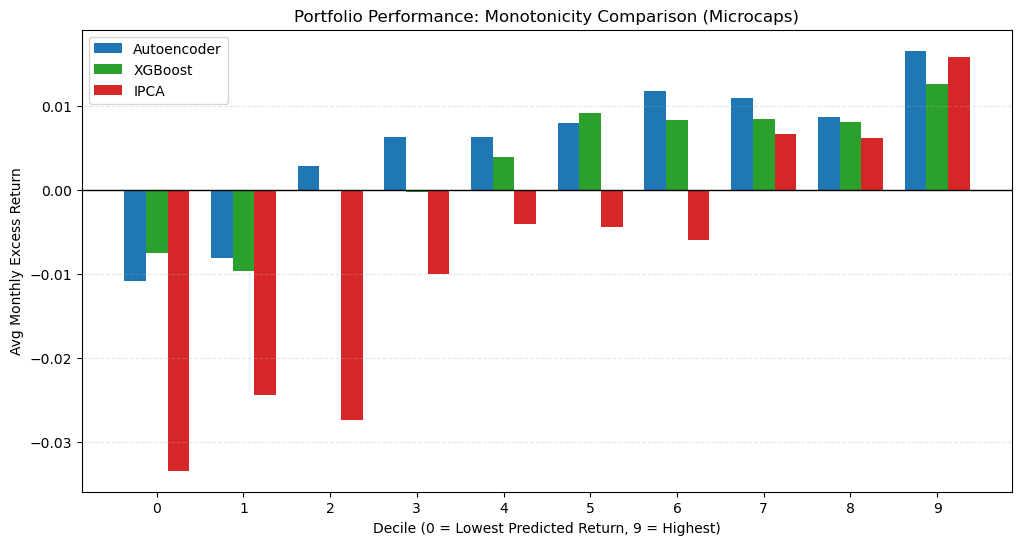

In [193]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import xgboost as xgb

def calculate_decile_portfolios(res_df, label):
    """
    Groups predictions into deciles monthly and calculates equal-weighted returns.
    """
    # 1. Assign Deciles monthly based on PREDICTED ranks
    res_df = res_df.with_columns(
        ((pl.col("pred").rank(descending=False).over("month") - 1) / 
         pl.count().over("month") * 10).floor().cast(pl.Int32).clip(0, 9).alias("decile")
    )

    # 2. Aggregate average monthly return per decile
    decile_stats = res_df.group_by("decile").agg(
        pl.col("actual").mean().alias("avg_monthly_return")
    ).sort("decile")

    print(f"--- {label} Results Processed ---")
    return decile_stats

# --- 1. Extract IPCA Predictions ---
def get_ipca_results(model, R_test, Z_test, mask_test, test_df, window=60):
    test_months = sorted(test_df["month"].unique())
    gamma = model.gamma
    K = model.K
    T = R_test.shape[1]
    factors, rows = [], []
    
    for t in range(T):
        idx = mask_test[:, t]
        if not idx.any():
            factors.append(np.zeros(K))
            continue
        
        Rt = R_test[idx, t]
        # Handle intercept logic: slice Z if Gamma is (11, K) but Z is (N, T, 12)
        Zt_lag = Z_test[idx, t, 1:] if gamma.shape[0] == (Z_test.shape[2] - 1) else Z_test[idx, t]
        
        # Estimate current month factor
        ft = np.linalg.solve(gamma.T @ Zt_lag.T @ Zt_lag @ gamma, gamma.T @ Zt_lag.T @ Rt)
        factors.append(ft)
        
        if t >= window:
            f_bar = np.mean(factors[t-window:t], axis=0)
            preds = Zt_lag @ gamma @ f_bar
            month_val = test_months[t]
            for a, p in zip(Rt, preds):
                rows.append({"month": month_val, "actual": a, "pred": p})
    return pl.from_dicts(rows)

# --- 2. Extract XGBoost Predictions ---
def get_xgb_results(model, R_test, Z_test, mask_test, test_df):
    test_months = sorted(test_df["month"].unique())
    rows = []
    for t in range(1, Z_test.shape[1]):
        idx = mask_test[:, t]
        # XGBoost needs the previous month's characteristics
        valid_Z = ~np.isnan(Z_test[:, t-1, 1]) 
        combined_idx = idx & valid_Z
        if combined_idx.any():
            # Slice off intercept for XGBoost input
            Z_prev = Z_test[combined_idx, t-1, 1:]
            actuals = R_test[combined_idx, t]
            preds = model.predict(xgb.DMatrix(Z_prev))
            month_val = test_months[t]
            for a, p in zip(actuals, preds):
                rows.append({"month": month_val, "actual": a, "pred": p})
    return pl.from_dicts(rows)

# --- 3. Align Autoencoder Predictions ---
# Replicate the exact month-filtering logic from your evaluate_oos_r2 function
ae_months = []
test_months_sorted = sorted(test_df["month"].unique())
for m in test_months_sorted:
    df_m = test_df.filter(pl.col("month") == m).drop_nulls(subset=chars + ["excess_ret"])
    if len(df_m) < 5 + 5: continue # Matching your K+5 threshold
    ae_months.extend([m] * len(df_m))

ae_results_df = pl.DataFrame({
    "month": ae_months,
    "actual": y_true_final,
    "pred": y_pred_final
})

# --- Execution ---
print("Processing portfolios for all models...")
ipca_res = calculate_decile_portfolios(get_ipca_results(IPCA_model, R_test, Z_test, mask_test, test_df), "IPCA")
xgb_res  = calculate_decile_portfolios(get_xgb_results(xgb_model, R_test, Z_test, mask_test, test_df), "XGBoost")
ae_res   = calculate_decile_portfolios(ae_results_df, "Autoencoder")

# --- Visualization ---
plt.figure(figsize=(12, 6))
deciles = np.arange(10)
w = 0.25

plt.bar(deciles - w, ae_res["avg_monthly_return"], width=w, label="Autoencoder", color='#1f77b4')
plt.bar(deciles, xgb_res["avg_monthly_return"], width=w, label="XGBoost", color='#2ca02c')
plt.bar(deciles + w, ipca_res["avg_monthly_return"], width=w, label="IPCA", color='#d62728')

plt.axhline(0, color='black', lw=1)
plt.xticks(deciles)
plt.xlabel("Decile (0 = Lowest Predicted Return, 9 = Highest)")
plt.ylabel("Avg Monthly Excess Return")
plt.title("Portfolio Performance: Monotonicity Comparison (Microcaps)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

Calculating characteristic importance for all models...


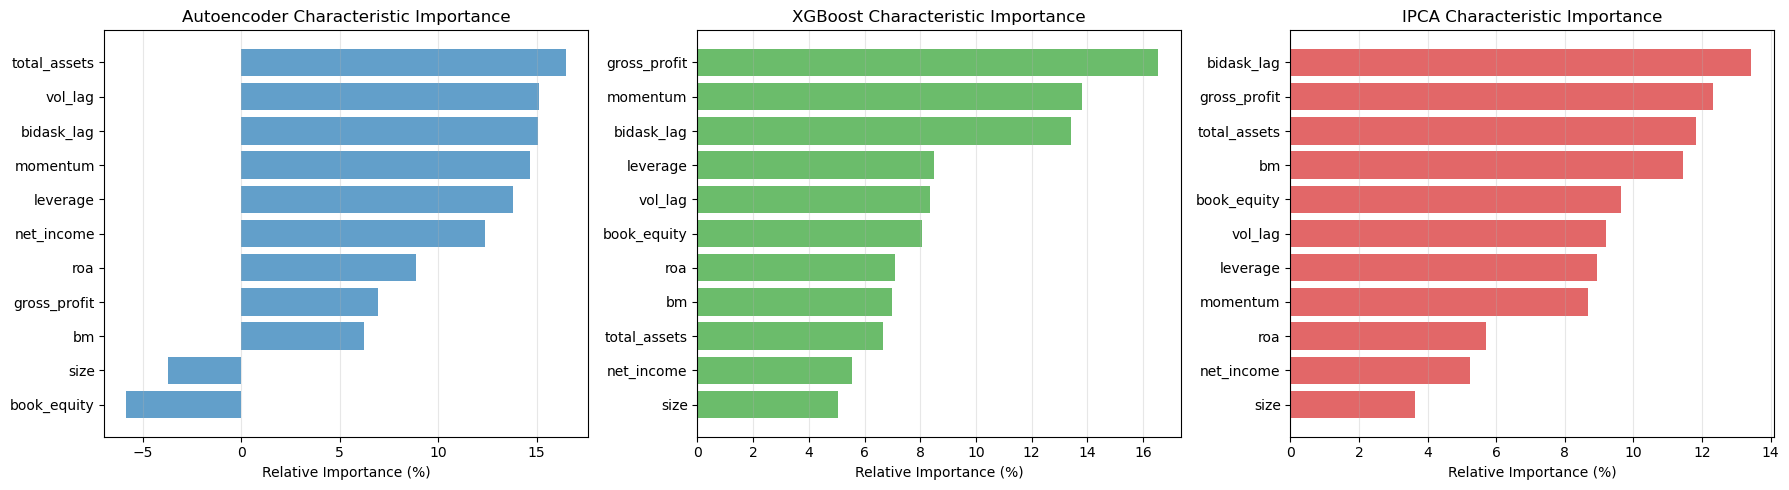


Top 3 characteristics by model:

Autoencoder:
  total_assets: 16.49%
  vol_lag: 15.10%
  bidask_lag: 15.05%

XGBoost:
  gross_profit: 16.53%
  momentum: 13.80%
  bidask_lag: 13.40%

IPCA:
  bidask_lag: 13.43%
  gross_profit: 12.32%
  total_assets: 11.81%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def calculate_char_importance_ae(model, train_df, chars, n_samples=1000):
    """Calculate characteristic importance for Autoencoder using permutation."""
    model.eval()
    

    sample_df = train_df.sample(n=min(n_samples, len(train_df))).drop_nulls(subset=chars)
    Z_base = torch.tensor(sample_df[chars].to_numpy(), dtype=torch.float32)
    
    with torch.no_grad():
    
        betas_base = model.forward_betas(Z_base).numpy()
        base_variance = np.var(betas_base, axis=0).sum() 
        
        importances = {}
        for i, char in enumerate(chars):
            # Permute characteristic i
            Z_perm = Z_base.clone()
            Z_perm[:, i] = Z_perm[torch.randperm(Z_perm.shape[0]), i]
            
            betas_perm = model.forward_betas(Z_perm).numpy()
            perm_variance = np.var(betas_perm, axis=0).sum()
            
            # Importance = reduction in beta variance when permuted
            importances[char] = base_variance - perm_variance
    
    return importances

def calculate_char_importance_ipca(model, chars):
    """Calculate characteristic importance for IPCA using gamma magnitudes."""
    # For IPCA, importance is the L2 norm of gamma for each characteristic
    # Skip intercept if present
    start_idx = 1 if model.gamma.shape[0] == len(chars) + 1 else 0
    importances = {}
    for i, char in enumerate(chars):
        importances[char] = np.linalg.norm(model.gamma[start_idx + i, :])
    return importances

def calculate_char_importance_xgb(model):
    """Calculate characteristic importance for XGBoost using feature importance."""
    importance_dict = model.get_score(importance_type='gain')
    # XGBoost uses f0, f1, f2, etc.
    importances = {}
    for i, char in enumerate(chars):
        key = f'f{i}'
        importances[char] = importance_dict.get(key, 0.0)
    return importances

print("Calculating characteristic importance for all models...")
ae_importance = calculate_char_importance_ae(ae_model, train_df, chars)
ipca_importance = calculate_char_importance_ipca(IPCA_model, chars)
xgb_importance = calculate_char_importance_xgb(xgb_model)

# Normalize importances to 0-100 scale for each model
def normalize_importance(imp_dict):
    total = sum(imp_dict.values())
    return {k: (v/total)*100 if total > 0 else 0 for k, v in imp_dict.items()}

ae_importance_norm = normalize_importance(ae_importance)
ipca_importance_norm = normalize_importance(ipca_importance)
xgb_importance_norm = normalize_importance(xgb_importance)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_data = [
    (ae_importance_norm, "Autoencoder", '#1f77b4'),
    (xgb_importance_norm, "XGBoost", '#2ca02c'),
    (ipca_importance_norm, "IPCA", '#d62728')
]

for ax, (imp_dict, title, color) in zip(axes, model_data):
    chars_sorted = sorted(imp_dict.items(), key=lambda x: x[1], reverse=True)
    names = [c[0] for c in chars_sorted]
    values = [c[1] for c in chars_sorted]
    
    ax.barh(names, values, color=color, alpha=0.7)
    ax.set_xlabel('Relative Importance (%)')
    ax.set_title(f'{title} Characteristic Importance')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTop 3 characteristics by model:")
for imp_dict, name, _ in model_data:
    top3 = sorted(imp_dict.items(), key=lambda x: x[1], reverse=True)[:3]
    print(f"\n{name}:")
    for char, val in top3:
        print(f"  {char}: {val:.2f}%")


Generating comprehensive PDP analysis...


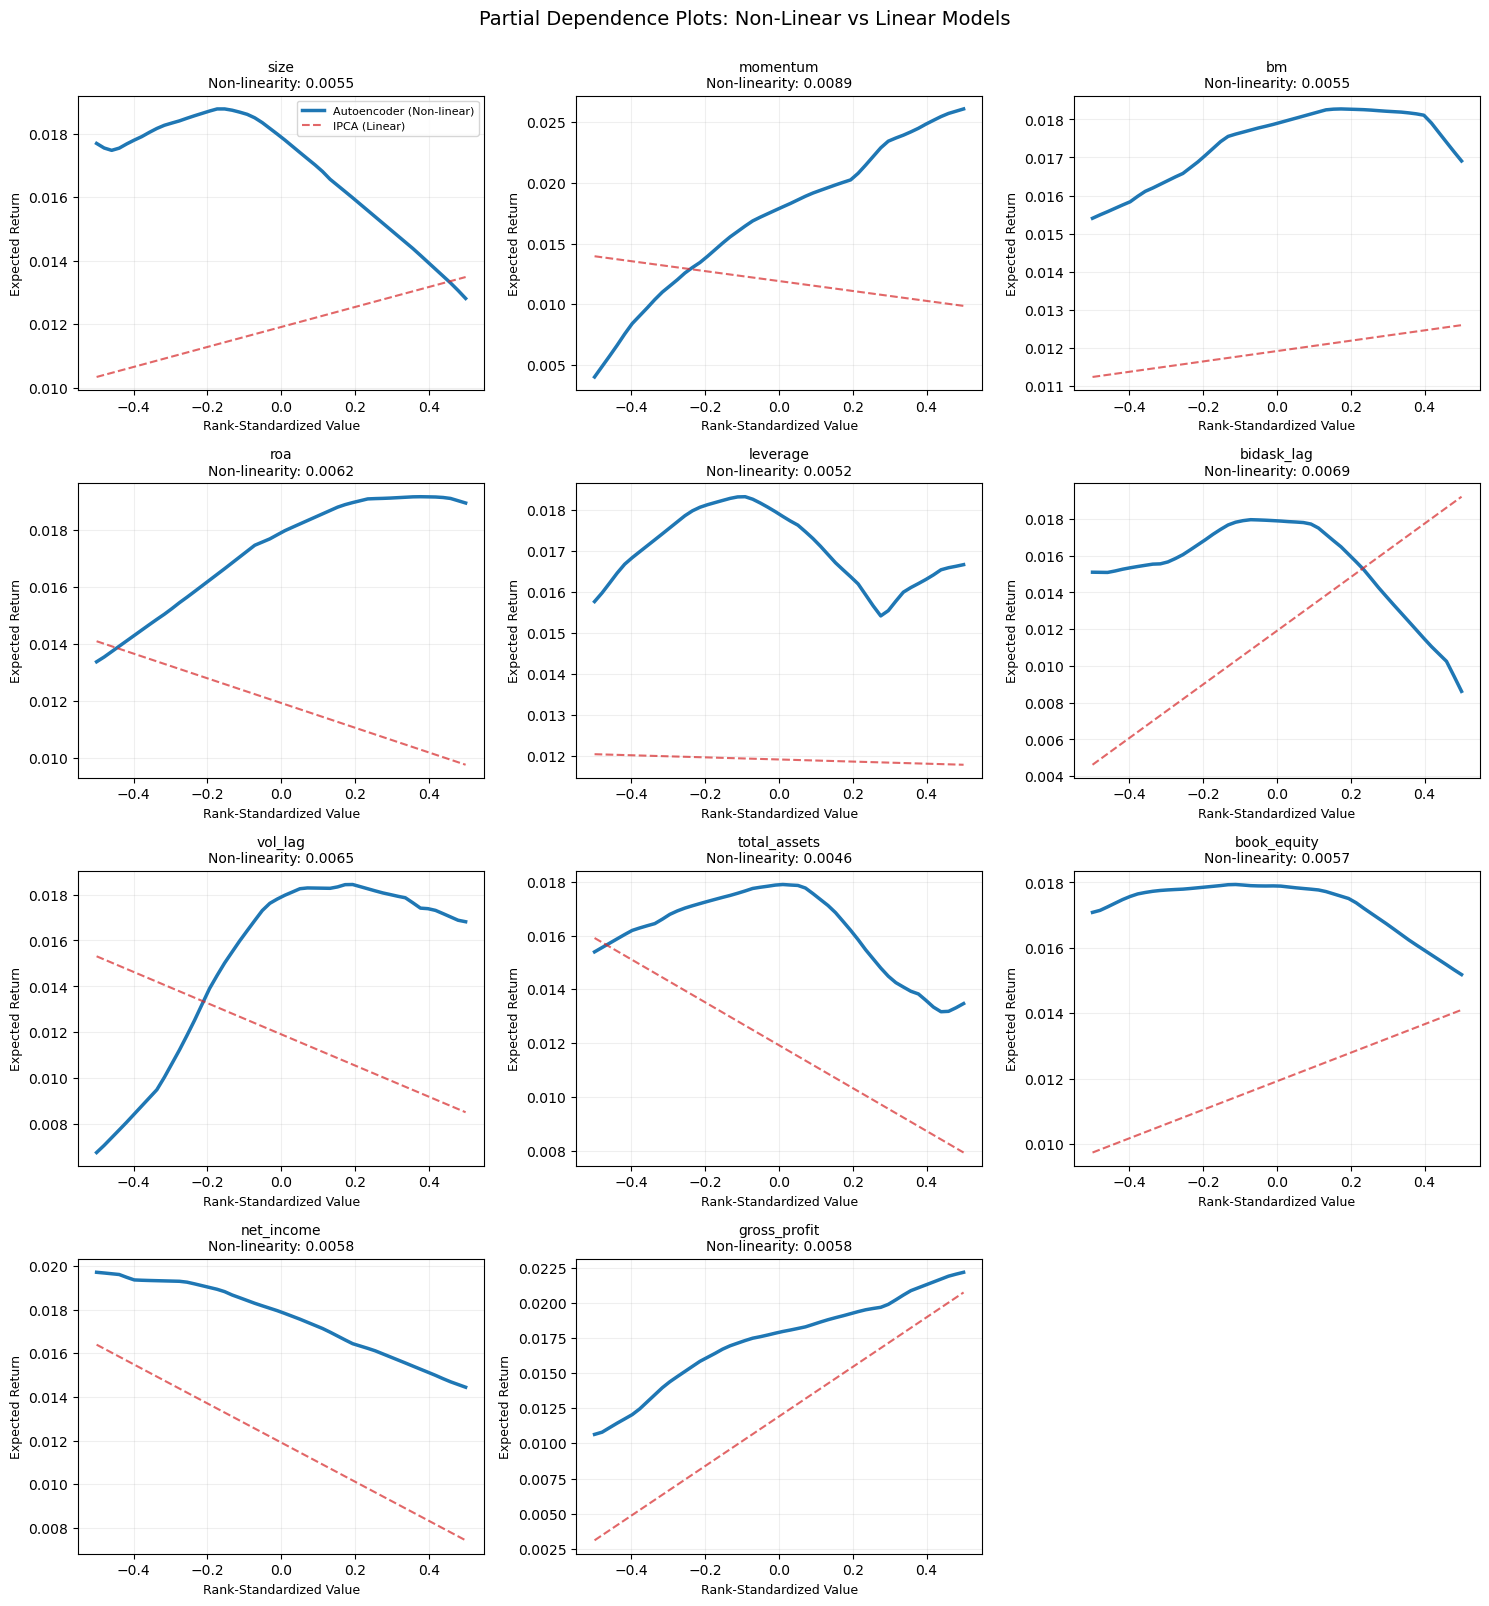

In [ ]:
def plot_all_pdp_grid():
    """Create a grid of PDPs for all characteristics."""
    n_chars = len(chars)
    n_cols = 3
    n_rows = (n_chars + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_chars > 1 else [axes]
    
    x_range = np.linspace(-0.5, 0.5, 50)
    
    for idx, target_char in enumerate(chars):
        ax = axes[idx]
        char_idx = chars.index(target_char)
        
        ae_preds, ipca_preds = [], []
        for val in x_range:
            z = np.zeros(len(chars))
            z[char_idx] = val
            
            # IPCA prediction
            if IPCA_model.gamma.shape[0] == len(chars) + 1:
                z_ipca = np.concatenate([[1.0], z])
            else:
                z_ipca = z
            ipca_preds.append(np.dot(z_ipca @ IPCA_model.gamma, f_bar_ipca))
            
            # AE prediction
            z_t = torch.tensor(z, dtype=torch.float32).unsqueeze(0)
            with torch.no_grad():
                beta_val = ae_model.forward_betas(z_t).numpy().flatten()
            ae_preds.append(np.dot(beta_val, f_bar_ae))
        
        # Calculate non-linearity score (deviation from linear)
        ae_arr = np.array(ae_preds)
        ipca_arr = np.array(ipca_preds)
        nonlin_score = np.sqrt(np.mean((ae_arr - ipca_arr)**2))
        
        ax.plot(x_range, ae_preds, label='Autoencoder (Non-linear)', color='#1f77b4', lw=2.5)
        ax.plot(x_range, ipca_preds, label='IPCA (Linear)', color='#d62728', linestyle='--', alpha=0.7)
        ax.set_title(f'{target_char}\nNon-linearity: {nonlin_score:.4f}', fontsize=10)
        ax.set_xlabel('Rank-Standardized Value', fontsize=9)
        ax.set_ylabel('Expected Return', fontsize=9)
        ax.grid(True, alpha=0.2)
        if idx == 0:
            ax.legend(fontsize=8)
    
    # Hide extra subplots
    for idx in range(len(chars), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Partial Dependence Plots: Non-Linear vs Linear Models', fontsize=14, y=1.001)
    plt.tight_layout()
    plt.show()

print("Generating comprehensive PDP analysis...")
plot_all_pdp_grid()



Non-linearity Rankings (Higher = More Non-linear):
shape: (11, 5)
┌────────────────┬──────────┬───────────────┬─────────────┬────────────────────┐
│ characteristic ┆ rmse     ┆ max_curvature ┆ correlation ┆ nonlinearity_score │
│ ---            ┆ ---      ┆ ---           ┆ ---         ┆ ---                │
│ str            ┆ f64      ┆ f64           ┆ f64         ┆ f64                │
╞════════════════╪══════════╪═══════════════╪═════════════╪════════════════════╡
│ bidask_lag     ┆ 0.00687  ┆ 0.000196      ┆ -0.545668   ┆ 0.000002           │
│ momentum       ┆ 0.008876 ┆ 0.000111      ┆ -0.988876   ┆ 0.000002           │
│ vol_lag        ┆ 0.006436 ┆ 0.000093      ┆ -0.847951   ┆ 0.000001           │
│ roa            ┆ 0.006182 ┆ 0.000045      ┆ -0.955357   ┆ 5.4515e-7          │
│ leverage       ┆ 0.005183 ┆ 0.000172      ┆ 0.406701    ┆ 5.2748e-7          │
│ …              ┆ …        ┆ …             ┆ …           ┆ …                  │
│ book_equity    ┆ 0.005698 ┆ 0.000032    

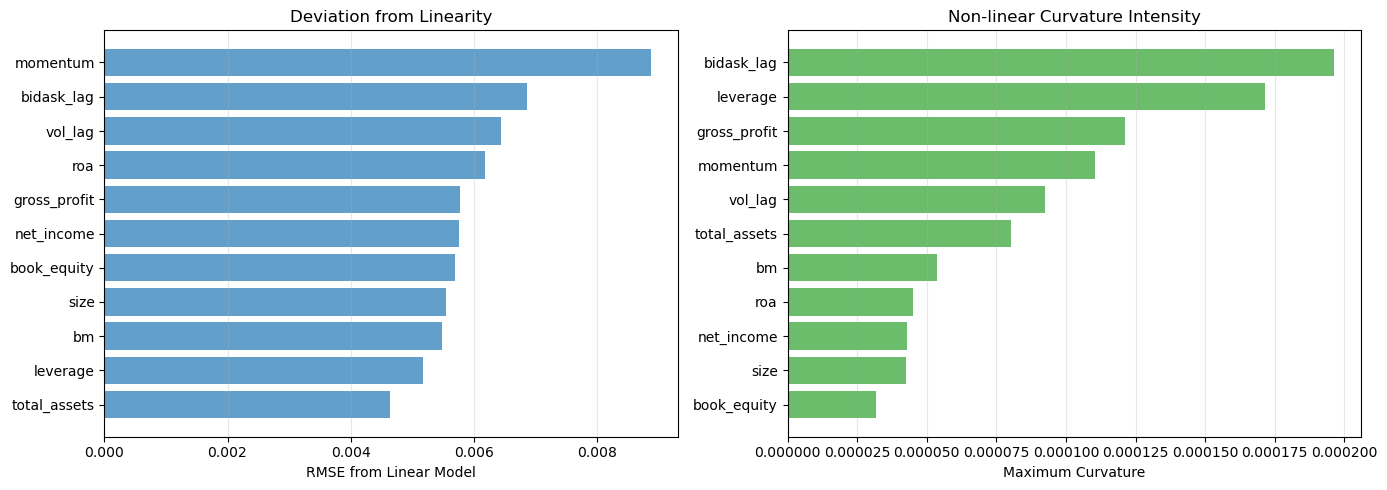

In [ ]:

def quantify_nonlinearity():
    """Calculate non-linearity metrics for each characteristic."""
    x_range = np.linspace(-0.5, 0.5, 100)
    results = []
    
    for target_char in chars:
        char_idx = chars.index(target_char)
        ae_preds, ipca_preds = [], []
        
        for val in x_range:
            z = np.zeros(len(chars))
            z[char_idx] = val
            
            # IPCA
            if IPCA_model.gamma.shape[0] == len(chars) + 1:
                z_ipca = np.concatenate([[1.0], z])
            else:
                z_ipca = z
            ipca_preds.append(np.dot(z_ipca @ IPCA_model.gamma, f_bar_ipca))
            
            # AE
            z_t = torch.tensor(z, dtype=torch.float32).unsqueeze(0)
            with torch.no_grad():
                beta_val = ae_model.forward_betas(z_t).numpy().flatten()
            ae_preds.append(np.dot(beta_val, f_bar_ae))
        
        ae_arr = np.array(ae_preds)
        ipca_arr = np.array(ipca_preds)
        
        # Metrics
        rmse = np.sqrt(np.mean((ae_arr - ipca_arr)**2))
        
        # Curvature: second derivative approximation
        ae_diff2 = np.diff(ae_arr, n=2)
        max_curvature = np.max(np.abs(ae_diff2))
        
        # Correlation (how similar the shapes are)
        correlation = np.corrcoef(ae_arr, ipca_arr)[0, 1]
        
        results.append({
            'characteristic': target_char,
            'rmse': rmse,
            'max_curvature': max_curvature,
            'correlation': correlation,
            'nonlinearity_score': rmse * (1 - correlation) * max_curvature
        })
    
    return pl.DataFrame(results)

nonlin_df = quantify_nonlinearity()
nonlin_sorted = nonlin_df.sort('nonlinearity_score', descending=True)

print("\nNon-linearity Rankings (Higher = More Non-linear):")
print(nonlin_sorted)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: RMSE from linear model
ax1 = axes[0]
sorted_rmse = nonlin_sorted.sort('rmse', descending=True)
ax1.barh(sorted_rmse['characteristic'], sorted_rmse['rmse'], color='#1f77b4', alpha=0.7)
ax1.set_xlabel('RMSE from Linear Model')
ax1.set_title('Deviation from Linearity')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Max curvature
ax2 = axes[1]
sorted_curv = nonlin_sorted.sort('max_curvature', descending=True)
ax2.barh(sorted_curv['characteristic'], sorted_curv['max_curvature'], color='#2ca02c', alpha=0.7)
ax2.set_xlabel('Maximum Curvature')
ax2.set_title('Non-linear Curvature Intensity')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


Generating interaction effect visualizations...


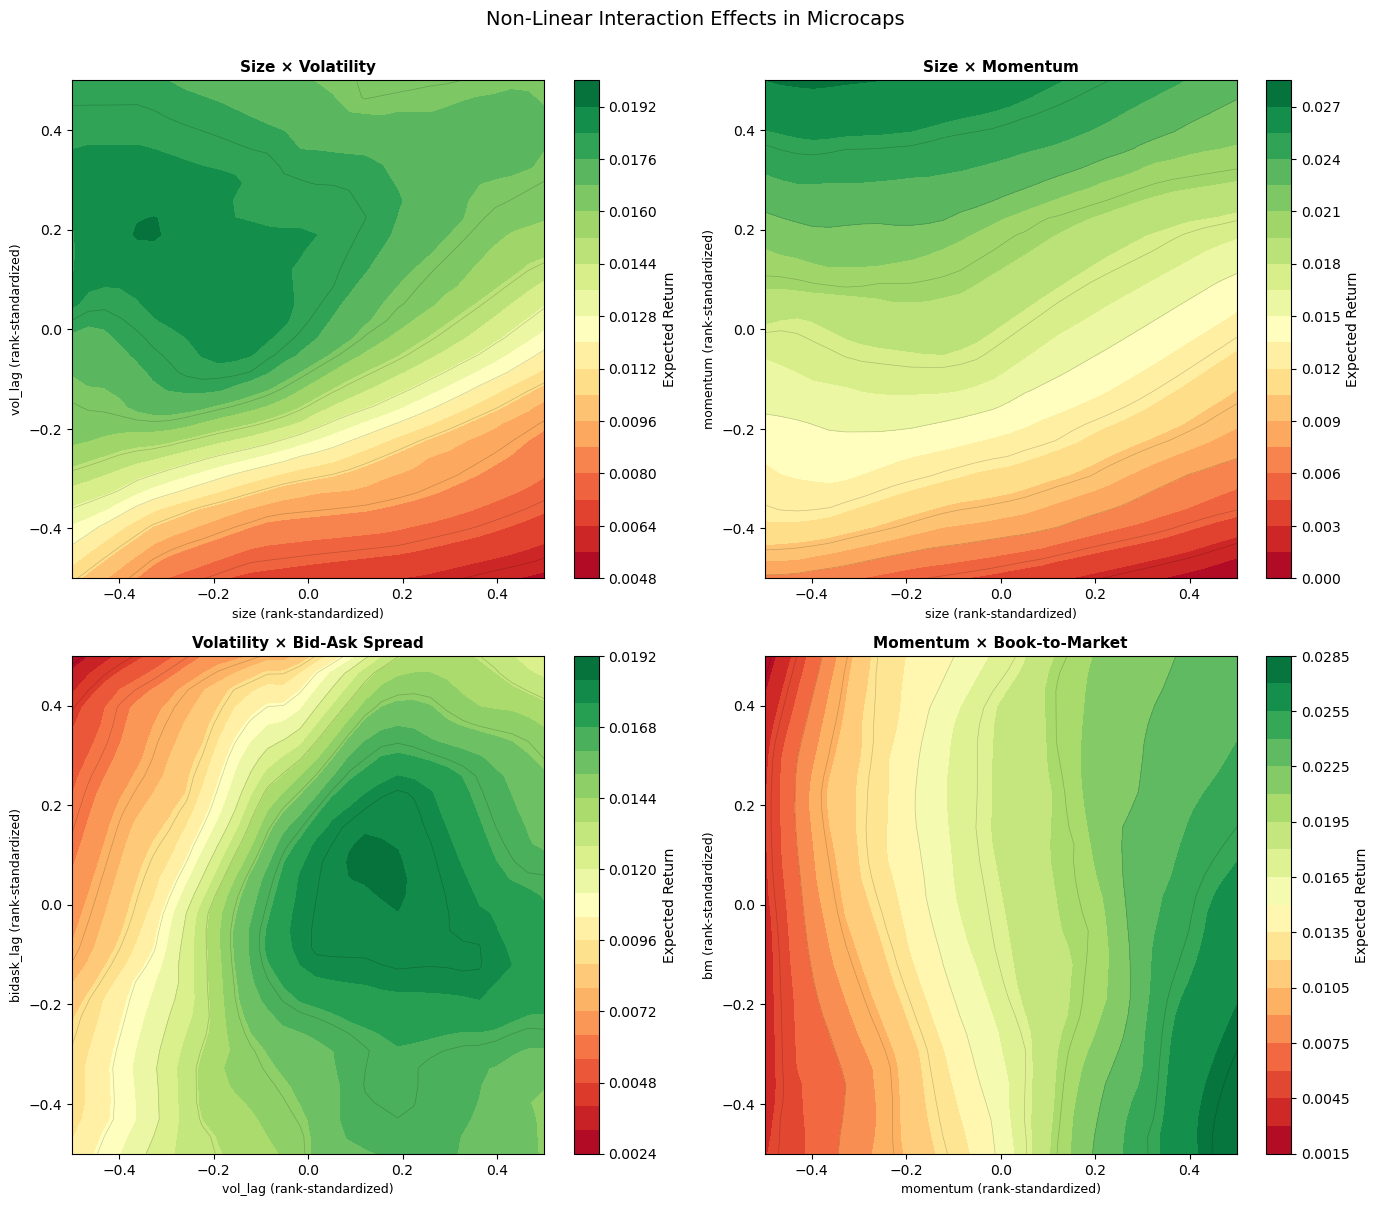

In [ ]:

def plot_key_interactions():
    """Plot interaction heatmaps for key characteristic pairs."""
    # Key interactions for microcaps
    interactions = [
        ('size', 'vol_lag', 'Size × Volatility'),
        ('size', 'momentum', 'Size × Momentum'),
        ('vol_lag', 'bidask_lag', 'Volatility × Bid-Ask Spread'),
        ('momentum', 'bm', 'Momentum × Book-to-Market')
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for idx, (c1, c2, title) in enumerate(interactions):
        if c1 not in chars or c2 not in chars:
            continue
            
        ax = axes[idx]
        res = 30
        x1 = np.linspace(-0.5, 0.5, res)
        x2 = np.linspace(-0.5, 0.5, res)
        X1, X2 = np.meshgrid(x1, x2)
        
        Z_grid = np.zeros((X1.size, len(chars)))
        Z_grid[:, chars.index(c1)] = X1.flatten()
        Z_grid[:, chars.index(c2)] = X2.flatten()
        
        with torch.no_grad():
            betas = ae_model.forward_betas(torch.tensor(Z_grid, dtype=torch.float32)).numpy()
        preds = (betas @ f_bar_ae).reshape(X1.shape)
        
        im = ax.contourf(X1, X2, preds, levels=20, cmap='RdYlGn')
        plt.colorbar(im, ax=ax, label='Expected Return')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel(f'{c1} (rank-standardized)', fontsize=9)
        ax.set_ylabel(f'{c2} (rank-standardized)', fontsize=9)
        
        # Add contour lines for clarity
        ax.contour(X1, X2, preds, levels=10, colors='black', alpha=0.2, linewidths=0.5)
    
    plt.suptitle('Non-Linear Interaction Effects in Microcaps', fontsize=14, y=1.001)
    plt.tight_layout()
    plt.show()

print("Generating interaction effect visualizations...")
plot_key_interactions()
